In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yaml
from tensorflow import keras
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

I0000 00:00:1777470008.943501 1882052 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777470008.970977 1882052 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777470010.276993 1882052 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


our models and our yaml config are imported

In [2]:
ae = tf.keras.models.load_model('training/ae_mnist.keras')
decoder = ae.get_layer('functional_1')
encoder = ae.get_layer('functional')

with open("configs/ae_config.yaml", "r") as f:
    config = yaml.safe_load(f)

W0000 00:00:1777470065.080797 1901913 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777470065.122111 1882052 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


we prepare the data to do some tests

In [3]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

x_train = np.pad(x_train, ((0,0), (2,2), (2,2), (0,0)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2), (0,0)), mode='constant')

let's test our generator. To do that a 7 is generated and in 10 images it's slightly turned into a 2. it seems to work pretty well

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


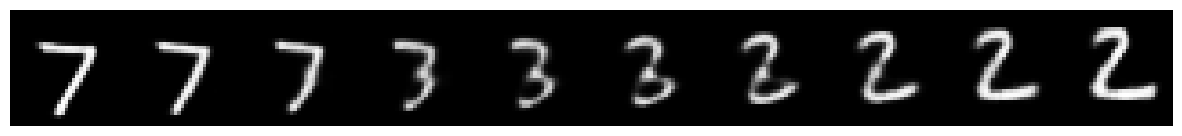

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [9]:
code_A = encoder.predict(x_test[0:1])
code_B = encoder.predict(x_test[1:2])

steps = 10
grid = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

latent_dim = config['model_params']['latent_dim']
code_A = encoder.predict(x_test[0:1])
code_B = np.random.normal(size=(1, latent_dim))

However if now we decide to go from a random point to another radom point the model seems to give weird results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


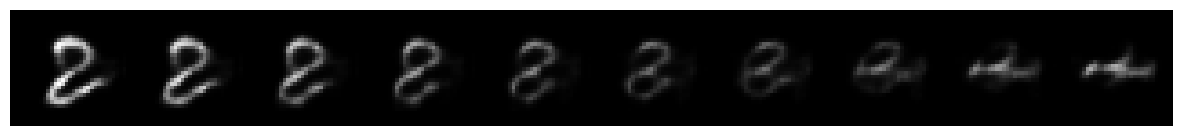

In [15]:
latent_dim = config['model_params']['latent_dim']
code_A = np.random.normal(size=(1, latent_dim))
code_B = np.random.normal(size=(1, latent_dim))

steps = 10
grid = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

To see the issue we decide to project the 10 dimensions od the latent space in 2 dimensions. First with the 2 more importants dimensions with PCA.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step


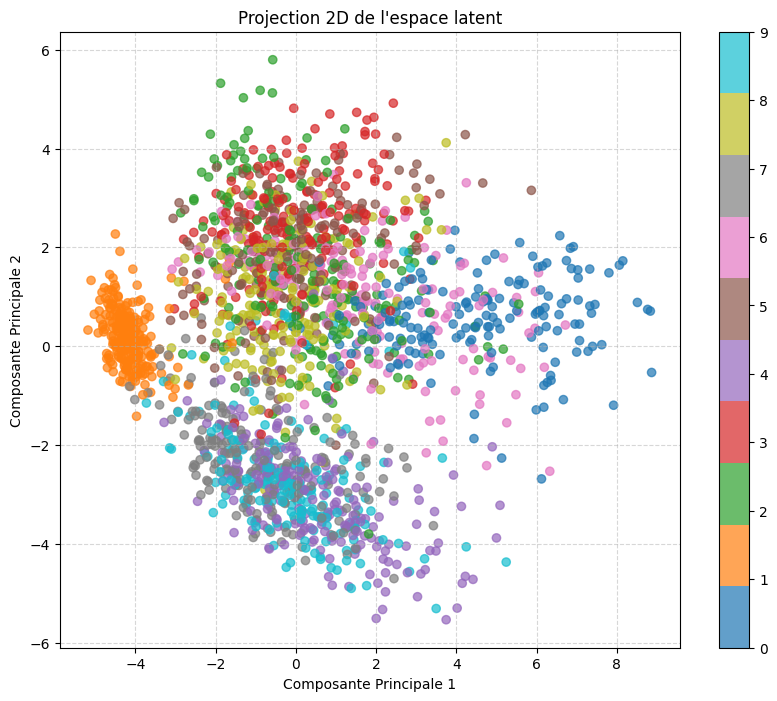

In [7]:
n_samples = 2000
codes_latents = encoder.predict(x_test[:n_samples])

pca = PCA(n_components=2)
codes_2d = pca.fit_transform(codes_latents)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test[:n_samples], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("Projection 2D de l'espace latent")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

We notice that this is a mess and we can also notice that there is some space with nothing in it. To have a better conclusion let's see what we have when we try to represent the distances between the points in 10 dimensions into a 2D projection.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step


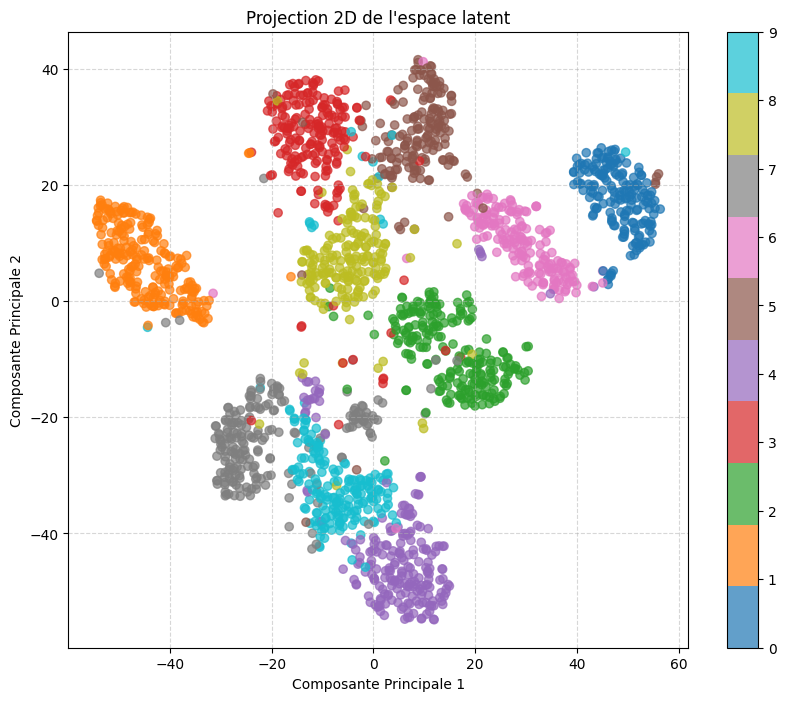

In [8]:
n_samples = 2000
codes_latents = encoder.predict(x_test[:n_samples])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
codes_2d = tsne.fit_transform(codes_latents)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test[:n_samples], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("Projection 2D de l'espace latent")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

There is interesting thing to say, first we now see the the clusters. Second we are sure now there is an issue of space it would be more interesting to have our points more distributed in the space; That explains the werid result of the random points in the space. Let's see how the VAE can produce better results